In [2]:
library(limma)
library(Biobase)
library(dplyr)
library(ggplot2)
library(magrittr)
library(ggrepel)

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following object is masked from ‘package:limma’:

    plotMA


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
    table, tapply, union, unique, unsplit, which.max, which.min


Welcome to Bioconductor

    Vignettes contain introductory material; view with
    'browseVignettes()'. To cite Bioconductor, see
    'citation("Biobase")', and for packages 'citation("pkgname")'.



Attaching package: ‘dplyr’


The following object is masked from ‘package:Biobase’:

    combine


The following

Expression Set object

In [3]:
data <- read.csv("extdata/mrna20k_lmci.csv", header=TRUE)

In [4]:
data_1 = data[,c(-1,-2)]

In [5]:
rownames(data_1) = data$index

In [6]:
data_2 = t(data_1)

In [7]:
subtype_info<-read.csv("extdata/cn_emci_lmci_ad_clin_pseudotime.csv",header=TRUE)
table(subtype_info$SNF)
name_lmci1<-subtype_info$PID[which(subtype_info$SNF=="lmcisubtype1")]
name_lmci2<-subtype_info$PID[which(subtype_info$SNF=="lmcisubtype2")]


          AD           CN emcisubtype1 emcisubtype2 lmcisubtype1 lmcisubtype2 
         339          534          108           93           85          115 

In [8]:
# subset clusters for c=2 SNF MRNA + METAB
data_subset_1=as.matrix(data_2[,name_lmci1])
data_subset_2=as.matrix(data_2[,name_lmci2])
dim(data_subset_1)
dim(data_subset_2)

data_subset = cbind(data_subset_1,data_subset_2)

dataset <- ExpressionSet(assayData=as.matrix(data_subset))

sub1 = dim(data_subset_1)[2]
sub2 = dim(data_subset_2)[2]
design = cbind(c(c(rep(1, sub1)),c(rep(0, sub2))),c(c(rep(0, sub1)),c(rep(1, sub2))))
colnames(design) <- c("subset1","subset2")

[1] 20032    85

[1] 20032   115

In [10]:
fit <- lmFit(data_subset, design)
cont.matrix <- makeContrasts(contrasts = "subset2-subset1", levels=design) # subset1 as control
fit2 <- contrasts.fit(fit, cont.matrix)
fit2 <- eBayes(fit2, trend=FALSE)
limma_result_fit <- topTable(fit2,  coef=1, n=Inf)
limma_result_fit$gene_symbol <- row.names(limma_result_fit)

In [11]:
limma_result_fit

,logFC,AveExpr,t,P.Value,adj.P.Val,B,gene_symbol
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
RPS4Y1,-3.5305596,8.254540,-8.005448,9.362739e-14,7.096772e-10,20.71346,RPS4Y1
KDM6A,0.6182169,4.557910,7.996819,9.873958e-14,7.096772e-10,20.66254,KDM6A
XIST,1.7408174,3.207370,7.984863,1.062815e-13,7.096772e-10,20.59204,XIST
DDX3Y,-1.8641008,4.891695,-7.919837,1.584558e-13,7.302174e-10,20.20954,DDX3Y
CARS,-0.2824215,8.278890,-7.896985,1.822627e-13,7.302174e-10,20.07549,CARS
NANS,-0.2507100,8.270430,-7.793099,3.435072e-13,1.146856e-09,19.46863,NANS
ACTR1A,-0.3361990,7.592015,-7.723723,5.232586e-13,1.497417e-09,19.06570,ACTR1A
GPR183,0.5578143,8.068355,7.649303,8.200765e-13,2.053471e-09,18.63559,GPR183
TMEM205,-0.3224737,7.879660,-7.582437,1.225595e-12,2.640784e-09,18.25104,TMEM205


Warning message:
“Removed 19703 rows containing missing values (`geom_text_repel()`).”
Warning message:
“ggrepel: 324 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Saving 6.67 x 6.67 in image
Warning message:
“Removed 19703 rows containing missing values (`geom_text_repel()`).”
Warning message:
“ggrepel: 324 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


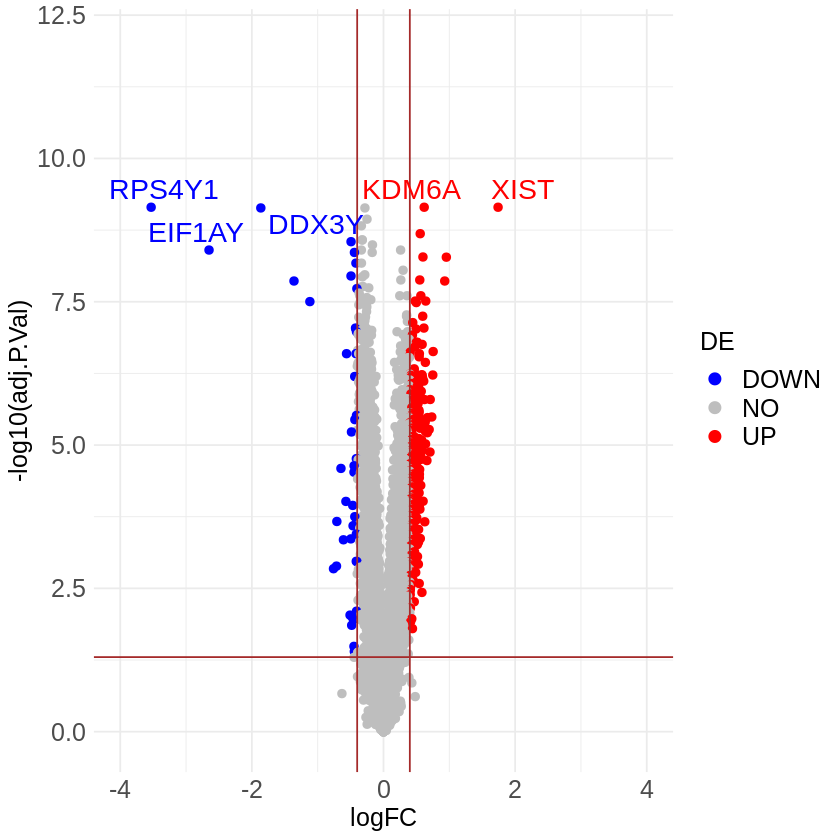

In [14]:
# plot volcano

fold_cutoff = 0.4

limma_result_fit$diffexpressed <- "NO"
# if log2Foldchange > 0.5 and pvalue < 0.05, set as "UP" 
limma_result_fit$diffexpressed[limma_result_fit$logFC > fold_cutoff & limma_result_fit$adj.P.Val < 0.05] <- "UP"
# if log2Foldchange < -0.5 and pvalue < 0.05, set as "DOWN"
limma_result_fit$diffexpressed[limma_result_fit$logFC < -fold_cutoff & limma_result_fit$adj.P.Val < 0.05] <- "DOWN"

limma_result_fit$delabel <- NA
limma_result_fit$delabel[limma_result_fit$diffexpressed != "NO"] <- limma_result_fit$gene_symbol[limma_result_fit$diffexpressed != "NO"]

ggplot(data=limma_result_fit, aes(x=logFC, y=-log10(adj.P.Val),col=diffexpressed)) +
        geom_point(size=2) +
        theme_minimal() +
        scale_color_manual(breaks=c("DOWN","NO","UP"),values=c("blue", "grey", "red")) +
        guides(color=guide_legend(title = "DE",override.aes = list(size = 3))) +
        geom_vline(xintercept=c(-fold_cutoff, fold_cutoff), col="brown") +
        geom_hline(yintercept=-log10(0.05), col="brown") + 
        xlim(-4, 4) +ylim(-0.1,12) +
        theme(axis.title = element_text(size = 15),axis.text=element_text(size=15),legend.title=element_text(size=15),legend.text=element_text(size=15))+
        geom_text_repel(aes(label=delabel),size=6,max.overlaps=5)

ggsave("figs/RP_2g.png",dpi=600)  

In [ ]:
limma_DE = limma_result_fit[which(limma_result_fit$diffexpressed != "NO"), ] 

In [ ]:
limma_DE

In [ ]:
rownames(limma_DE)

In [ ]:
#write.csv(limma_DE,"DE_results/RP_limmaDE_LMCI.csv")

In [ ]:
top10 <- topTable(fit2,  coef=1, n=10,sort.by="p")
top10